<a href="https://colab.research.google.com/github/rodrigorissettoterra/ai-model-studies/blob/main/010_rag_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Como chunking, Top-K, embeddings e reranking afetam qualidade, grounding e custo?

**Área:** LLMOps / Generative AI  
**Tipo de problema:** Avaliação sistemática de Retrieval-Augmented Generation

### Pergunta de estudo

> Quais decisões de arquitetura produzem o melhor equilíbrio entre recuperação, grounding, qualidade da resposta, latência e volume de contexto em um sistema RAG?

O Study 009 construiu um pipeline RAG de referência.  
Este notebook transforma as principais decisões daquele pipeline em **variáveis experimentais**.

### Variáveis avaliadas

1. **Chunk size**
2. **Chunk overlap**
3. **Top-K**
4. **Embedding model**
5. **Reranking com CrossEncoder**

### Métricas de retrieval

- Hit@1;
- Hit@K;
- MRR;
- Source Precision@K;
- Answer Support Rate;
- latência.

### Métricas de geração

- Exact Match;
- Token F1;
- Answer Containment;
- Groundedness por LLM-as-a-Judge;
- Answer Relevance por LLM-as-a-Judge;
- tokens de contexto;
- latência.

### Filosofia do estudo

Um RAG não deve ser otimizado apenas por uma métrica.

Uma configuração pode:

- recuperar mais documentos relevantes;
- aumentar latência;
- enviar contexto excessivo ao LLM;
- adicionar ruído;
- melhorar recall e piorar precisão;
- melhorar grounding sem melhorar a resposta final.

O objetivo é observar esses **trade-offs de forma mensurável**.


## 1. Configuração do ambiente

O notebook foi projetado para Google Colab.

A maior parte da grade de retrieval pode ser executada em CPU.  
GPU é recomendada para embeddings maiores, reranking e geração com LLM.


In [1]:
!pip -q install -U datasets sentence-transformers faiss-cpu transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.3/611.3 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.5 MB/s eta 0:00:00


In [2]:
import gc
import json
import random
import re
import string
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import faiss

from datasets import load_dataset
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------------------------------------
# Tamanho do benchmark
# -------------------------------------------------------

CORPUS_CONTEXTS = 250
RETRIEVAL_EVAL_QUESTIONS = 80
GENERATION_EVAL_QUESTIONS = 12

# -------------------------------------------------------
# Grade experimental
# -------------------------------------------------------

CHUNK_SIZES = [80, 120, 180]
CHUNK_OVERLAPS = [0, 30]
TOP_K_VALUES = [2, 4, 8]

EMBEDDING_MODELS = {
    "MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
    "MPNet": "sentence-transformers/multi-qa-mpnet-base-dot-v1",
}

RERANKER_NAME = "cross-encoder/ms-marco-MiniLM-L6-v2"

# Quantos candidatos o reranker recebe antes de selecionar Top-K.
RERANK_CANDIDATES = 20

# Quantas configurações seguem para avaliação com geração.
TOP_CONFIGS_FOR_GENERATION = 3

# -------------------------------------------------------
# LLM
# -------------------------------------------------------

GENERATION_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("PyTorch:", torch.__version__)
print("GPU disponível:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128
GPU disponível: True


## 2. Benchmark — SQuAD 1.1

O benchmark utiliza o split de validação do SQuAD.

Cada pergunta possui:

- um contexto original;
- uma resposta de referência;
- a identificação do documento que contém a evidência.

Isso permite avaliar separadamente:

1. se o retriever encontra a fonte correta;
2. se o contexto recuperado contém a resposta;
3. se o LLM produz uma resposta correta e grounded.


In [3]:
squad = load_dataset("rajpurkar/squad", split="validation")
raw_df = squad.to_pandas()

contexts_df = (
    raw_df[["title", "context"]]
    .drop_duplicates("context")
    .sample(
        n=min(CORPUS_CONTEXTS, raw_df["context"].nunique()),
        random_state=SEED,
    )
    .reset_index(drop=True)
)

contexts_df["source_id"] = [
    f"doc_{i:04d}"
    for i in range(len(contexts_df))
]

qa_pool = raw_df.merge(
    contexts_df[["context", "source_id"]],
    on="context",
    how="inner",
)

qa_pool["reference_answer"] = qa_pool["answers"].apply(
    lambda answer_dict: answer_dict["text"][0]
)

retrieval_eval_df = qa_pool.sample(
    n=min(RETRIEVAL_EVAL_QUESTIONS, len(qa_pool)),
    random_state=SEED,
).reset_index(drop=True)

generation_eval_df = qa_pool.sample(
    n=min(GENERATION_EVAL_QUESTIONS, len(qa_pool)),
    random_state=SEED + 1,
).reset_index(drop=True)

print("Documentos no corpus:", len(contexts_df))
print("Perguntas disponíveis:", len(qa_pool))
print("Perguntas — retrieval eval:", len(retrieval_eval_df))
print("Perguntas — generation eval:", len(generation_eval_df))

display(
    generation_eval_df[
        ["source_id", "title", "question", "reference_answer"]
    ].head()
)


README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 14.5MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 1.82MB            

plain_text/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Documentos no corpus: 250
Perguntas disponíveis: 1218
Perguntas — retrieval eval: 80
Perguntas — generation eval: 12


,source_id,title,question,reference_answer
0,doc_0001,Huguenot,What did the Edict do for Huguenots in France?,granted the Protestants equality with Catholics
1,doc_0221,Warsaw,"What theatre was the best example of ""Polish m...",Wojciech Bogusławski Theatre
2,doc_0191,Victoria_and_Albert_Museum,When did the V&A acquired the Costiff collection?,2002
3,doc_0196,Ctenophora,What does the ctenophora use to swim?,‘combs’ – groups of cilia
4,doc_0069,Geology,Where do thrust faults form?,In the shallow crust


## 3. Funções de chunking

O chunking será tratado como parte da arquitetura, e não como detalhe de pré-processamento.

### Trade-off esperado

**Chunks menores**
- maior granularidade;
- menos ruído por chunk;
- maior número de vetores;
- maior risco de separar pergunta e evidência.

**Chunks maiores**
- mais contexto por unidade;
- menos vetores;
- maior chance de incluir evidência;
- maior volume de texto irrelevante.

O overlap pode preservar continuidade, mas também aumenta redundância.


In [4]:
def split_into_chunks(text, chunk_size, overlap):
    words = str(text).split()

    if chunk_size <= overlap:
        raise ValueError("chunk_size deve ser maior que overlap.")

    chunks = []
    start = 0

    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk = " ".join(words[start:end]).strip()

        if chunk:
            chunks.append(chunk)

        if end == len(words):
            break

        start = end - overlap

    return chunks


def build_chunks(contexts, chunk_size, overlap):
    rows = []

    for _, row in contexts.iterrows():
        chunks = split_into_chunks(
            row["context"],
            chunk_size=chunk_size,
            overlap=overlap,
        )

        for chunk_index, chunk_text in enumerate(chunks):
            rows.append({
                "source_id": row["source_id"],
                "title": row["title"],
                "chunk_index": chunk_index,
                "text": chunk_text,
            })

    chunks_df = pd.DataFrame(rows)

    chunks_df["chunk_id"] = [
        f"chunk_{i:05d}"
        for i in range(len(chunks_df))
    ]

    return chunks_df


## 4. Funções de embeddings e índice

Para busca assimétrica, são utilizados `encode_document()` e `encode_query()` quando disponíveis.

Os vetores são normalizados e indexados em FAISS com `IndexFlatIP`, permitindo busca exata por similaridade.


In [5]:
def encode_documents(model, texts):
    if hasattr(model, "encode_document"):
        embeddings = model.encode_document(
            texts,
            normalize_embeddings=True,
            show_progress_bar=False,
        )
    else:
        embeddings = model.encode(
            texts,
            normalize_embeddings=True,
            show_progress_bar=False,
        )

    return np.asarray(embeddings, dtype="float32")


def encode_queries(model, texts):
    if hasattr(model, "encode_query"):
        embeddings = model.encode_query(
            texts,
            normalize_embeddings=True,
            show_progress_bar=False,
        )
    else:
        embeddings = model.encode(
            texts,
            normalize_embeddings=True,
            show_progress_bar=False,
        )

    return np.asarray(embeddings, dtype="float32")


def build_faiss_index(embeddings):
    dimension = embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)
    index.add(embeddings)
    return index


## 5. Métricas de retrieval

### Hit@1 / Hit@K

Verifica se ao menos um chunk da fonte correta foi recuperado.

### MRR

Valoriza configurações que colocam a primeira fonte relevante nas primeiras posições.

### Source Precision@K

Proporção dos chunks recuperados que pertencem ao documento correto.

Esta métrica ajuda a detectar um problema comum:

> aumentar Top-K pode melhorar recall, mas também adicionar contexto irrelevante.

### Answer Support

Verifica se uma resposta de referência aparece textualmente no contexto recuperado.

É uma aproximação simples de **context recall**, não uma avaliação semântica completa.


In [6]:
def normalize_text(text):
    text = str(text).lower()
    text = "".join(
        char
        for char in text
        if char not in string.punctuation
    )
    return " ".join(text.split())


def answer_supported(context, references):
    normalized_context = normalize_text(context)

    for reference in references:
        normalized_reference = normalize_text(reference)

        if (
            normalized_reference
            and normalized_reference in normalized_context
        ):
            return 1

    return 0


## 6. Avaliador de uma configuração de retrieval

Uma configuração é definida por:

```text
embedding model
+ chunk size
+ overlap
+ Top-K
+ reranker on/off
```

Quando o reranker está ativo:

1. o bi-encoder recupera um conjunto maior de candidatos;
2. o CrossEncoder reavalia os pares `(query, chunk)`;
3. apenas os melhores Top-K seguem para o contexto final.


In [7]:
def evaluate_retrieval_configuration(
    chunks_df,
    document_embeddings,
    embedding_model,
    vector_index,
    questions_df,
    top_k,
    reranker=None,
    rerank_candidates=20,
):
    query_texts = questions_df["question"].tolist()

    query_embeddings = encode_queries(
        embedding_model,
        query_texts,
    )

    candidate_k = (
        min(rerank_candidates, len(chunks_df))
        if reranker is not None
        else top_k
    )

    search_start = time.perf_counter()

    scores, indices = vector_index.search(
        query_embeddings,
        candidate_k,
    )

    search_elapsed = time.perf_counter() - search_start

    rows = []
    rerank_elapsed = 0.0

    for query_index, row in questions_df.iterrows():
        candidate_indices = [
            int(idx)
            for idx in indices[query_index]
        ]

        candidate_scores = [
            float(score)
            for score in scores[query_index]
        ]

        candidates = chunks_df.iloc[
            candidate_indices
        ].copy()

        candidates["dense_score"] = candidate_scores

        if reranker is not None:
            pairs = [
                [row["question"], text]
                for text in candidates["text"].tolist()
            ]

            rerank_start = time.perf_counter()

            cross_scores = reranker.predict(
                pairs,
                show_progress_bar=False,
            )

            rerank_elapsed += (
                time.perf_counter()
                - rerank_start
            )

            candidates["rerank_score"] = cross_scores

            candidates = (
                candidates
                .sort_values(
                    "rerank_score",
                    ascending=False,
                )
                .head(top_k)
            )

        else:
            candidates = candidates.head(top_k)

        sources = candidates["source_id"].tolist()

        relevant_positions = [
            rank
            for rank, source_id
            in enumerate(sources, start=1)
            if source_id == row["source_id"]
        ]

        first_rank = (
            relevant_positions[0]
            if relevant_positions
            else None
        )

        retrieved_context = " ".join(
            candidates["text"].tolist()
        )

        references = row["answers"]["text"]

        rows.append({
            "hit@1": int(
                row["source_id"] in sources[:1]
            ),
            "hit@k": int(
                row["source_id"] in sources
            ),
            "reciprocal_rank": (
                1.0 / first_rank
                if first_rank
                else 0.0
            ),
            "source_precision@k": (
                sum(
                    source_id == row["source_id"]
                    for source_id in sources
                )
                / len(sources)
                if sources
                else 0.0
            ),
            "answer_support": answer_supported(
                retrieved_context,
                references,
            ),
            "context_words": len(
                retrieved_context.split()
            ),
        })

    result_df = pd.DataFrame(rows)

    total_latency = (
        search_elapsed
        + rerank_elapsed
    )

    summary = {
        "Hit@1": result_df["hit@1"].mean(),
        "Hit@K": result_df["hit@k"].mean(),
        "MRR": result_df["reciprocal_rank"].mean(),
        "Source Precision@K":
            result_df["source_precision@k"].mean(),
        "Answer Support":
            result_df["answer_support"].mean(),
        "Avg Context Words":
            result_df["context_words"].mean(),
        "Retrieval Latency ms/query":
            total_latency / len(result_df) * 1000,
    }

    return summary, result_df


# Parte A — Grade experimental de retrieval

A etapa mais barata do RAG deve ser explorada primeiro.

Não faz sentido executar geração para dezenas de configurações ruins de retrieval.


## 7. Carregamento do reranker

CrossEncoders avaliam query e documento conjuntamente.

Eles costumam ser mais caros que bi-encoders, então são usados apenas sobre um conjunto pequeno de candidatos recuperados previamente.


In [8]:
reranker = CrossEncoder(
    RERANKER_NAME
)

print("Reranker:", RERANKER_NAME)


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Reranker: cross-encoder/ms-marco-MiniLM-L6-v2


## 8. Execução da grade

Para cada combinação de:

- embedding model;
- chunk size;
- overlap;
- Top-K;

o notebook avalia:

- sem reranking;
- com reranking.

O resultado é armazenado em um DataFrame para comparação posterior.


In [9]:
experiment_rows = []
experiment_details = {}

for embedding_label, embedding_name in EMBEDDING_MODELS.items():

    print(f"\n=== EMBEDDING: {embedding_label} ===")

    embedding_model = SentenceTransformer(
        embedding_name
    )

    for chunk_size in CHUNK_SIZES:

        for overlap in CHUNK_OVERLAPS:

            if overlap >= chunk_size:
                continue

            print(
                f"Chunk={chunk_size} | "
                f"Overlap={overlap}"
            )

            chunks_df = build_chunks(
                contexts_df,
                chunk_size,
                overlap,
            )

            embedding_start = time.perf_counter()

            document_embeddings = encode_documents(
                embedding_model,
                chunks_df["text"].tolist(),
            )

            embedding_elapsed = (
                time.perf_counter()
                - embedding_start
            )

            vector_index = build_faiss_index(
                document_embeddings
            )

            for top_k in TOP_K_VALUES:

                for use_reranker in [False, True]:

                    active_reranker = (
                        reranker
                        if use_reranker
                        else None
                    )

                    summary, detail_df = (
                        evaluate_retrieval_configuration(
                            chunks_df=chunks_df,
                            document_embeddings=document_embeddings,
                            embedding_model=embedding_model,
                            vector_index=vector_index,
                            questions_df=retrieval_eval_df,
                            top_k=top_k,
                            reranker=active_reranker,
                            rerank_candidates=RERANK_CANDIDATES,
                        )
                    )

                    config_id = (
                        f"{embedding_label}"
                        f"_c{chunk_size}"
                        f"_o{overlap}"
                        f"_k{top_k}"
                        f"_rr{int(use_reranker)}"
                    )

                    experiment_rows.append({
                        "Config": config_id,
                        "Embedding": embedding_label,
                        "Embedding Model": embedding_name,
                        "Chunk Size": chunk_size,
                        "Overlap": overlap,
                        "Top-K": top_k,
                        "Reranker": use_reranker,
                        "Chunks": len(chunks_df),
                        "Embedding Time s": embedding_elapsed,
                        **summary,
                    })

                    experiment_details[
                        config_id
                    ] = detail_df

            del (
                chunks_df,
                document_embeddings,
                vector_index,
            )

            gc.collect()

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    del embedding_model
    gc.collect()

retrieval_experiments = pd.DataFrame(
    experiment_rows
)

print(
    "Configurações avaliadas:",
    len(retrieval_experiments),
)



=== EMBEDDING: MiniLM ===


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Chunk=80 | Overlap=0
Chunk=80 | Overlap=30
Chunk=120 | Overlap=0
Chunk=120 | Overlap=30
Chunk=180 | Overlap=0
Chunk=180 | Overlap=30
Configurações avaliadas: 72


## 9. Ranking das configurações

Não será criada uma métrica composta arbitrária.

As configurações são ordenadas primeiro por:

1. **MRR**;
2. **Answer Support**;
3. **Source Precision@K**;
4. menor latência.

Isso mantém explícito o critério de seleção.


In [10]:
ranked_retrieval = (
    retrieval_experiments
    .sort_values(
        by=[
            "MRR",
            "Answer Support",
            "Source Precision@K",
            "Retrieval Latency ms/query",
        ],
        ascending=[
            False,
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    ranked_retrieval.head(15).round(4)
)


,Config,Embedding,Embedding Model,Chunk Size,Overlap,Top-K,Reranker,Chunks,Embedding Time s,Hit@1,Hit@K,MRR,Source Precision@K,Answer Support,Avg Context Words,Retrieval Latency ms/query
0,MPNet_c120_o30_k4_rr1,MPNet,sentence-transformers/multi-qa-mpnet-base-dot-v1,120,30,4,True,363,3.6340,0.9875,1.0000,0.9917,0.3219,1.0000,382.3750,41.0391
1,MPNet_c120_o30_k8_rr1,MPNet,sentence-transformers/multi-qa-mpnet-base-dot-v1,120,30,8,True,363,3.6340,0.9875,1.0000,0.9917,0.1641,1.0000,753.3875,41.2822
2,MPNet_c120_o30_k2_rr1,MPNet,sentence-transformers/multi-qa-mpnet-base-dot-v1,120,30,2,True,363,3.6340,0.9875,0.9875,0.9875,0.6062,0.9875,187.7375,46.0259
3,MPNet_c80_o0_k4_rr1,MPNet,sentence-transformers/multi-qa-mpnet-base-dot-v1,80,0,4,True,508,3.2680,0.9750,1.0000,0.9844,0.3594,1.0000,234.1625,30.8166
4,MPNet_c80_o0_k8_rr1,MPNet,sentence-transformers/multi-qa-mpnet-base-dot-v1,80,0,8,True,508,3.2680,0.9750,1.0000,0.9844,0.1969,1.0000,406.1000,26.3845
5,MPNet_c80_o0_k2_rr1,MPNet,sentence-transformers/multi-qa-mpnet-base-dot-v1,80,0,2,True,508,3.2680,0.9750,0.9875,0.9812,0.6312,0.9750,132.1750,26.7322
6,MiniLM_c120_o30_k4_rr1,MiniLM,sentence-transformers/all-MiniLM-L6-v2,120,30,4,True,363,0.5630,0.9750,0.9875,0.9792,0.3156,0.9875,382.4750,39.8926
7,MiniLM_c180_o30_k4_rr1,MiniLM,sentence-transformers/all-MiniLM-L6-v2,180,30,4,True,284,0.4965,0.9750,0.9875,0.9792,0.2656,0.9875,462.6250,57.7340
8,MPNet_c180_o30_k4_rr1,MPNet,sentence-transformers/multi-qa-mpnet-base-dot-v1,180,30,4,True,284,3.4880,0.9750,0.9875,0.9792,0.2656,0.9875,463.5625,58.2554
9,MiniLM_c180_o0_k4_rr1,MiniLM,sentence-transformers/all-MiniLM-L6-v2,180,0,4,True,283,0.4879,0.9750,0.9875,0.9792,0.2562,0.9875,454.3875,52.8087


## 10. Trade-off: MRR vs latência

Uma configuração superior em ranking pode exigir mais processamento.

O gráfico permite visualizar a relação entre qualidade de retrieval e latência.


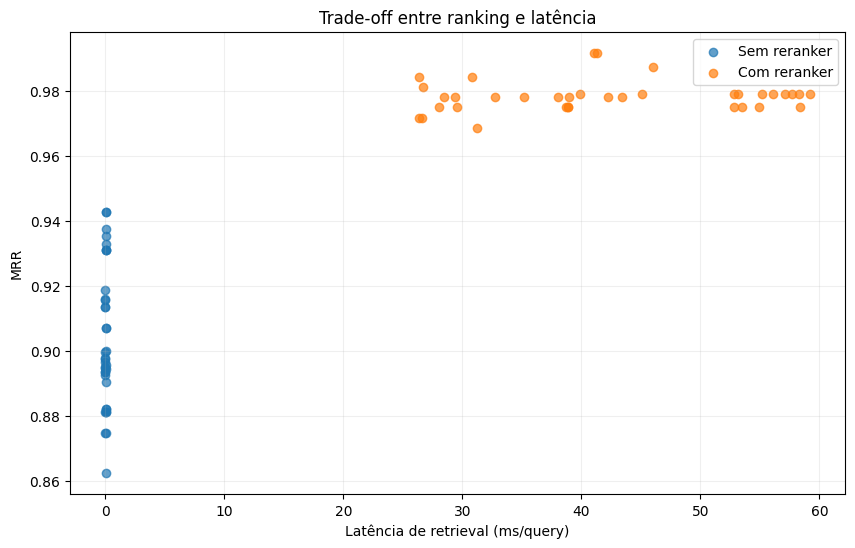

In [11]:
plt.figure(figsize=(10, 6))

for reranker_value, label in [
    (False, "Sem reranker"),
    (True, "Com reranker"),
]:
    subset = retrieval_experiments[
        retrieval_experiments["Reranker"]
        == reranker_value
    ]

    plt.scatter(
        subset["Retrieval Latency ms/query"],
        subset["MRR"],
        label=label,
        alpha=0.7,
    )

plt.xlabel("Latência de retrieval (ms/query)")
plt.ylabel("MRR")
plt.title("Trade-off entre ranking e latência")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 11. Efeito do Top-K

Aumentar Top-K pode melhorar a chance de recuperar evidência, mas também tende a aumentar o contexto entregue ao LLM.


In [12]:
topk_summary = (
    retrieval_experiments
    .groupby("Top-K")[
        [
            "Hit@K",
            "MRR",
            "Source Precision@K",
            "Answer Support",
            "Avg Context Words",
        ]
    ]
    .mean()
)

display(topk_summary.round(4))


,Hit@K,MRR,Source Precision@K,Answer Support,Avg Context Words
Top-K,,,,,
2,0.9521,0.9349,0.5721,0.9443,174.9042
4,0.9818,0.9439,0.3214,0.9776,341.0068
8,0.9870,0.9448,0.1712,0.9865,659.3120


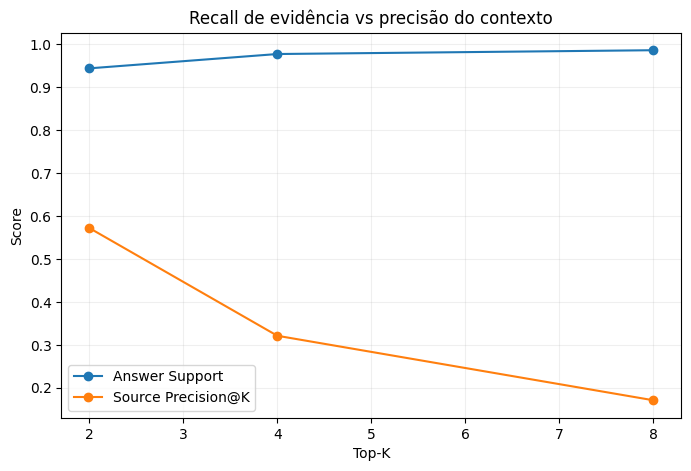

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    topk_summary.index,
    topk_summary["Answer Support"],
    marker="o",
    label="Answer Support",
)
plt.plot(
    topk_summary.index,
    topk_summary["Source Precision@K"],
    marker="o",
    label="Source Precision@K",
)
plt.xlabel("Top-K")
plt.ylabel("Score")
plt.title("Recall de evidência vs precisão do contexto")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 12. Efeito do chunk size


In [14]:
chunk_summary = (
    retrieval_experiments
    .groupby("Chunk Size")[
        [
            "Hit@K",
            "MRR",
            "Answer Support",
            "Avg Context Words",
        ]
    ]
    .mean()
)

display(chunk_summary.round(4))


,Hit@K,MRR,Answer Support,Avg Context Words
Chunk Size,,,,
80,0.9729,0.9392,0.9625,287.6234
120,0.9755,0.9412,0.9724,396.6594
180,0.9724,0.9432,0.9734,490.9401


## 13. Efeito do reranking

O reranking será comparado em média mantendo todas as demais configurações na grade.


In [15]:
reranker_summary = (
    retrieval_experiments
    .groupby("Reranker")[
        [
            "Hit@1",
            "Hit@K",
            "MRR",
            "Source Precision@K",
            "Answer Support",
            "Retrieval Latency ms/query",
        ]
    ]
    .mean()
    .rename(
        index={
            False: "Sem reranker",
            True: "Com reranker",
        }
    )
)

display(reranker_summary.round(4))


,Hit@1,Hit@K,MRR,Source Precision@K,Answer Support,Retrieval Latency ms/query
Reranker,,,,,,
Sem reranker,0.8604,0.9618,0.9039,0.3490,0.9556,0.0276
Com reranker,0.9750,0.9854,0.9785,0.3609,0.9833,42.0301


## 14. Seleção das configurações para geração

Somente as melhores configurações de retrieval seguirão para a etapa mais cara.

Para evitar avaliar variações quase idênticas, o notebook seleciona as primeiras configurações do ranking.


In [16]:
selected_configs = (
    ranked_retrieval
    .head(TOP_CONFIGS_FOR_GENERATION)
    .copy()
)

display(
    selected_configs[
        [
            "Config",
            "Embedding",
            "Chunk Size",
            "Overlap",
            "Top-K",
            "Reranker",
            "MRR",
            "Answer Support",
            "Source Precision@K",
            "Retrieval Latency ms/query",
        ]
    ]
    .round(4)
)


,Config,Embedding,Chunk Size,Overlap,Top-K,Reranker,MRR,Answer Support,Source Precision@K,Retrieval Latency ms/query
0,MPNet_c120_o30_k4_rr1,MPNet,120,30,4,True,0.9917,1.0000,0.3219,41.0391
1,MPNet_c120_o30_k8_rr1,MPNet,120,30,8,True,0.9917,1.0000,0.1641,41.2822
2,MPNet_c120_o30_k2_rr1,MPNet,120,30,2,True,0.9875,0.9875,0.6062,46.0259


# Parte B — Avaliação de geração

Agora avaliamos se melhor retrieval realmente produz melhores respostas.


## 15. LLM de geração e avaliação

O Qwen2.5-1.5B-Instruct será usado para:

1. gerar respostas;
2. executar uma avaliação estruturada de groundedness e relevance.

### Limitação importante

Usar um LLM como avaliador introduz subjetividade e possível viés.

Por isso, os scores de LLM-as-a-Judge são apresentados **junto** com métricas determinísticas, nunca como única fonte de verdade.


In [17]:
tokenizer = AutoTokenizer.from_pretrained(
    GENERATION_MODEL_NAME
)

generation_model = (
    AutoModelForCausalLM
    .from_pretrained(
        GENERATION_MODEL_NAME,
        dtype="auto",
        device_map="auto",
    )
)

print(
    "Modelo:",
    GENERATION_MODEL_NAME,
)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modelo: Qwen/Qwen2.5-1.5B-Instruct


In [18]:
def generate_chat(messages, max_new_tokens=120):
    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(generation_model.device)

    with torch.inference_mode():
        output = generation_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = output[
        :,
        inputs["input_ids"].shape[1]:,
    ]

    text = tokenizer.decode(
        new_tokens[0],
        skip_special_tokens=True,
    )

    return text.strip()


## 16. Métricas determinísticas de resposta


In [19]:
def normalize_answer(text):
    text = str(text).lower()

    text = "".join(
        char
        for char in text
        if char not in string.punctuation
    )

    text = re.sub(
        r"\b(a|an|the)\b",
        " ",
        text,
    )

    return " ".join(
        text.split()
    )


def exact_match(prediction, reference):
    return int(
        normalize_answer(prediction)
        ==
        normalize_answer(reference)
    )


def token_f1(prediction, reference):
    pred_tokens = (
        normalize_answer(prediction)
        .split()
    )

    ref_tokens = (
        normalize_answer(reference)
        .split()
    )

    if not pred_tokens or not ref_tokens:
        return 0.0

    common = (
        Counter(pred_tokens)
        &
        Counter(ref_tokens)
    )

    overlap = sum(
        common.values()
    )

    if overlap == 0:
        return 0.0

    precision = (
        overlap
        / len(pred_tokens)
    )

    recall = (
        overlap
        / len(ref_tokens)
    )

    return (
        2
        * precision
        * recall
        / (precision + recall)
    )


def best_over_references(
    prediction,
    references,
    metric,
):
    return max(
        metric(prediction, reference)
        for reference in references
    )


def containment(
    prediction,
    references,
):
    normalized_prediction = (
        normalize_answer(prediction)
    )

    return int(
        any(
            normalize_answer(reference)
            in normalized_prediction
            for reference in references
            if reference
        )
    )


## 17. Reconstrução de uma configuração

Cada configuração selecionada precisa reconstruir:

- chunks;
- embeddings;
- índice;
- embedding model.

O reranker global é reutilizado quando necessário.


In [20]:
def prepare_configuration(config_row):
    chunks_df = build_chunks(
        contexts_df,
        int(config_row["Chunk Size"]),
        int(config_row["Overlap"]),
    )

    embedding_model = SentenceTransformer(
        config_row["Embedding Model"]
    )

    document_embeddings = encode_documents(
        embedding_model,
        chunks_df["text"].tolist(),
    )

    vector_index = build_faiss_index(
        document_embeddings
    )

    return (
        chunks_df,
        embedding_model,
        vector_index,
    )


## 18. Retrieval operacional com e sem reranking


In [21]:
def retrieve_for_generation(
    question,
    chunks_df,
    embedding_model,
    vector_index,
    top_k,
    use_reranker,
):
    query_embedding = encode_queries(
        embedding_model,
        [question],
    )

    candidate_k = (
        min(
            RERANK_CANDIDATES,
            len(chunks_df),
        )
        if use_reranker
        else top_k
    )

    scores, indices = vector_index.search(
        query_embedding,
        candidate_k,
    )

    candidates = chunks_df.iloc[
        [int(idx) for idx in indices[0]]
    ].copy()

    candidates["dense_score"] = (
        scores[0]
    )

    if use_reranker:
        pairs = [
            [question, text]
            for text
            in candidates["text"].tolist()
        ]

        cross_scores = reranker.predict(
            pairs,
            show_progress_bar=False,
        )

        candidates["rerank_score"] = (
            cross_scores
        )

        candidates = (
            candidates
            .sort_values(
                "rerank_score",
                ascending=False,
            )
            .head(top_k)
        )

    else:
        candidates = candidates.head(top_k)

    return candidates.reset_index(drop=True)


## 19. Geração grounded

O prompt instrui o modelo a utilizar apenas o contexto recuperado e a se abster quando não houver evidência.


In [22]:
def build_context(retrieved):
    blocks = []

    for _, row in retrieved.iterrows():
        blocks.append(
            f"[SOURCE: {row['source_id']}]\n"
            f"{row['text']}"
        )

    return "\n\n".join(blocks)


def answer_from_context(question, context):
    messages = [
        {
            "role": "system",
            "content": (
                "Answer the question using only "
                "the provided context. "
                "If the context does not support "
                "the answer, say "
                "'I don't know based on the context.' "
                "Return only the short answer."
            ),
        },
        {
            "role": "user",
            "content": (
                f"QUESTION:\n{question}\n\n"
                f"CONTEXT:\n{context}"
            ),
        },
    ]

    return generate_chat(
        messages,
        max_new_tokens=80,
    )


## 20. LLM-as-a-Judge

O avaliador recebe:

- pergunta;
- contexto;
- resposta gerada.

Ele retorna dois scores binários:

### Groundedness

A resposta está sustentada pelo contexto?

### Answer Relevance

A resposta responde diretamente à pergunta?

O judge não recebe a resposta de referência para groundedness, reduzindo o risco de avaliar apenas similaridade com o gold answer.


In [23]:
def parse_json_object(text):
    match = re.search(
        r"\{.*\}",
        text,
        flags=re.S,
    )

    if not match:
        return None

    try:
        return json.loads(
            match.group(0)
        )
    except json.JSONDecodeError:
        return None


def judge_response(
    question,
    context,
    answer,
):
    messages = [
        {
            "role": "system",
            "content": (
                "You are evaluating a RAG answer. "
                "Return only valid JSON with integer "
                "scores 0 or 1. "
                "groundedness=1 only if every factual "
                "claim in the answer is supported by "
                "the provided context. "
                "answer_relevance=1 only if the answer "
                "directly addresses the question. "
                "Format: "
                '{"groundedness": 0, "answer_relevance": 0}'
            ),
        },
        {
            "role": "user",
            "content": (
                f"QUESTION:\n{question}\n\n"
                f"CONTEXT:\n{context}\n\n"
                f"ANSWER:\n{answer}"
            ),
        },
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=60,
    )

    parsed = parse_json_object(
        raw
    )

    if parsed is None:
        return {
            "groundedness": np.nan,
            "answer_relevance": np.nan,
            "judge_raw": raw,
        }

    return {
        "groundedness": int(
            bool(parsed.get(
                "groundedness",
                0,
            ))
        ),
        "answer_relevance": int(
            bool(parsed.get(
                "answer_relevance",
                0,
            ))
        ),
        "judge_raw": raw,
    }


## 21. Contagem de tokens

Como o modelo é local, não existe uma cobrança de API por token neste experimento.

Mesmo assim, a quantidade de tokens é uma boa proxy de:

- tamanho do prompt;
- uso de memória;
- latência;
- custo potencial em APIs comerciais.

Por isso registramos tokens de contexto e tokens totais do prompt.


In [24]:
def count_tokens(text):
    return len(
        tokenizer.encode(
            str(text),
            add_special_tokens=False,
        )
    )


## 22. Execução da avaliação de geração

Cada uma das melhores configurações é avaliada sobre o mesmo subconjunto de perguntas.


In [25]:
generation_rows = []

for _, config_row in selected_configs.iterrows():

    config_id = config_row["Config"]

    print(
        f"\n=== {config_id} ==="
    )

    (
        chunks_df,
        embedding_model,
        vector_index,
    ) = prepare_configuration(
        config_row
    )

    for i, row in generation_eval_df.iterrows():

        print(
            f"[{i + 1}/"
            f"{len(generation_eval_df)}] "
            f"{row['question'][:60]}"
        )

        retrieval_start = (
            time.perf_counter()
        )

        retrieved = retrieve_for_generation(
            question=row["question"],
            chunks_df=chunks_df,
            embedding_model=embedding_model,
            vector_index=vector_index,
            top_k=int(config_row["Top-K"]),
            use_reranker=bool(
                config_row["Reranker"]
            ),
        )

        retrieval_latency = (
            time.perf_counter()
            - retrieval_start
        )

        context = build_context(
            retrieved
        )

        generation_start = (
            time.perf_counter()
        )

        answer = answer_from_context(
            row["question"],
            context,
        )

        generation_latency = (
            time.perf_counter()
            - generation_start
        )

        judge_start = (
            time.perf_counter()
        )

        judge = judge_response(
            question=row["question"],
            context=context,
            answer=answer,
        )

        judge_latency = (
            time.perf_counter()
            - judge_start
        )

        references = row["answers"]["text"]

        generation_rows.append({
            "Config": config_id,
            "question": row["question"],
            "reference_answer": references[0],
            "answer": answer,

            "Exact Match":
                best_over_references(
                    answer,
                    references,
                    exact_match,
                ),

            "Token F1":
                best_over_references(
                    answer,
                    references,
                    token_f1,
                ),

            "Answer Containment":
                containment(
                    answer,
                    references,
                ),

            "Groundedness":
                judge["groundedness"],

            "Answer Relevance":
                judge["answer_relevance"],

            "Context Tokens":
                count_tokens(context),

            "Answer Tokens":
                count_tokens(answer),

            "Retrieval Latency s":
                retrieval_latency,

            "Generation Latency s":
                generation_latency,

            "Judge Latency s":
                judge_latency,

            "Total Latency s":
                (
                    retrieval_latency
                    + generation_latency
                ),
        })

    del (
        chunks_df,
        embedding_model,
        vector_index,
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


generation_results = pd.DataFrame(
    generation_rows
)

print(
    "Respostas avaliadas:",
    len(generation_results),
)



=== MPNet_c120_o30_k4_rr1 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[1/12] What did the Edict do for Huguenots in France?
[2/12] What theatre was the best example of "Polish monumental thea
[3/12] When did the V&A acquired the Costiff collection?
[4/12] What does the ctenophora use to swim?
[5/12] Where do thrust faults form?
[6/12] Full size working engines on what vehicles sometimes use osc
[7/12] What is the name of the United Kingdom operation for BSkyB?
[8/12] What public policy school found it's home in the building th
[9/12] What did the king do to regarding Huguenot education?
[10/12] What events are often associated with volcanism and igneous 
[11/12] What modern city is located on the original Huguenot colony?
[12/12] Who did BSkyB team up with because it was not part of the co

=== MPNet_c120_o30_k8_rr1 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[1/12] What did the Edict do for Huguenots in France?
[2/12] What theatre was the best example of "Polish monumental thea
[3/12] When did the V&A acquired the Costiff collection?
[4/12] What does the ctenophora use to swim?
[5/12] Where do thrust faults form?
[6/12] Full size working engines on what vehicles sometimes use osc
[7/12] What is the name of the United Kingdom operation for BSkyB?
[8/12] What public policy school found it's home in the building th
[9/12] What did the king do to regarding Huguenot education?
[10/12] What events are often associated with volcanism and igneous 
[11/12] What modern city is located on the original Huguenot colony?
[12/12] Who did BSkyB team up with because it was not part of the co

=== MPNet_c120_o30_k2_rr1 ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[1/12] What did the Edict do for Huguenots in France?
[2/12] What theatre was the best example of "Polish monumental thea
[3/12] When did the V&A acquired the Costiff collection?
[4/12] What does the ctenophora use to swim?
[5/12] Where do thrust faults form?
[6/12] Full size working engines on what vehicles sometimes use osc
[7/12] What is the name of the United Kingdom operation for BSkyB?
[8/12] What public policy school found it's home in the building th
[9/12] What did the king do to regarding Huguenot education?
[10/12] What events are often associated with volcanism and igneous 
[11/12] What modern city is located on the original Huguenot colony?
[12/12] Who did BSkyB team up with because it was not part of the co
Respostas avaliadas: 36


## 23. Resultados agregados de geração


In [26]:
generation_summary = (
    generation_results
    .groupby("Config")[
        [
            "Exact Match",
            "Token F1",
            "Answer Containment",
            "Groundedness",
            "Answer Relevance",
            "Context Tokens",
            "Retrieval Latency s",
            "Generation Latency s",
            "Total Latency s",
        ]
    ]
    .mean()
    .sort_values(
        by=[
            "Token F1",
            "Groundedness",
            "Answer Relevance",
        ],
        ascending=False,
    )
)

display(
    generation_summary.round(4)
)


,Exact Match,Token F1,Answer Containment,Groundedness,Answer Relevance,Context Tokens,Retrieval Latency s,Generation Latency s,Total Latency s
Config,,,,,,,,,
MPNet_c120_o30_k4_rr1,0.5833,0.6111,0.6667,0.2500,0.2500,615.3333,0.0526,1.0929,1.1455
MPNet_c120_o30_k8_rr1,0.4167,0.4683,0.5000,0.1667,0.1667,1198.1667,0.0544,1.8407,1.8951
MPNet_c120_o30_k2_rr1,0.3333,0.4321,0.3333,0.3333,0.3333,300.1667,0.0565,0.6652,0.7217


## 24. Qualidade vs tamanho do contexto

Mais contexto não significa necessariamente melhor resposta.

Contextos maiores:

- consomem mais tokens;
- podem aumentar latência;
- podem adicionar informação irrelevante;
- podem dificultar grounding.

O gráfico compara Token F1 com o tamanho médio do contexto.


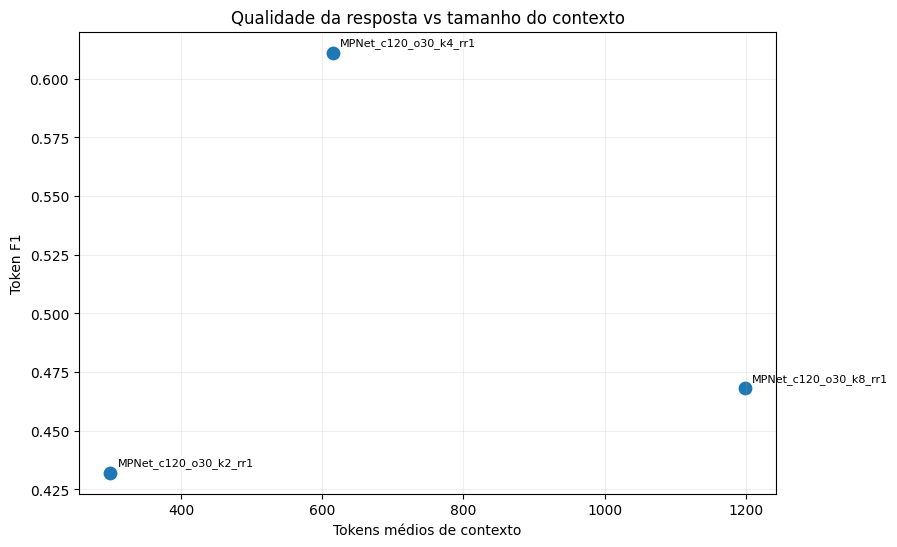

In [27]:
plt.figure(figsize=(9, 6))

plt.scatter(
    generation_summary["Context Tokens"],
    generation_summary["Token F1"],
    s=80,
)

for config_id, row in generation_summary.iterrows():
    plt.annotate(
        config_id,
        (
            row["Context Tokens"],
            row["Token F1"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Tokens médios de contexto")
plt.ylabel("Token F1")
plt.title("Qualidade da resposta vs tamanho do contexto")
plt.grid(alpha=0.2)
plt.show()


## 25. Groundedness vs Answer Relevance

Uma resposta pode ser grounded e ainda não responder bem à pergunta.

Da mesma forma, uma resposta pode parecer relevante, mas conter afirmações não sustentadas pelo contexto.


In [28]:
display(
    generation_summary[
        [
            "Token F1",
            "Groundedness",
            "Answer Relevance",
            "Context Tokens",
            "Total Latency s",
        ]
    ]
    .round(4)
)


,Token F1,Groundedness,Answer Relevance,Context Tokens,Total Latency s
Config,,,,,
MPNet_c120_o30_k4_rr1,0.6111,0.2500,0.2500,615.3333,1.1455
MPNet_c120_o30_k8_rr1,0.4683,0.1667,0.1667,1198.1667,1.8951
MPNet_c120_o30_k2_rr1,0.4321,0.3333,0.3333,300.1667,0.7217


## 26. Pareto simples: qualidade e latência

Não será criada uma função de custo arbitrária.

O objetivo é visualizar quais configurações apresentam melhor compromisso entre Token F1 e latência total.


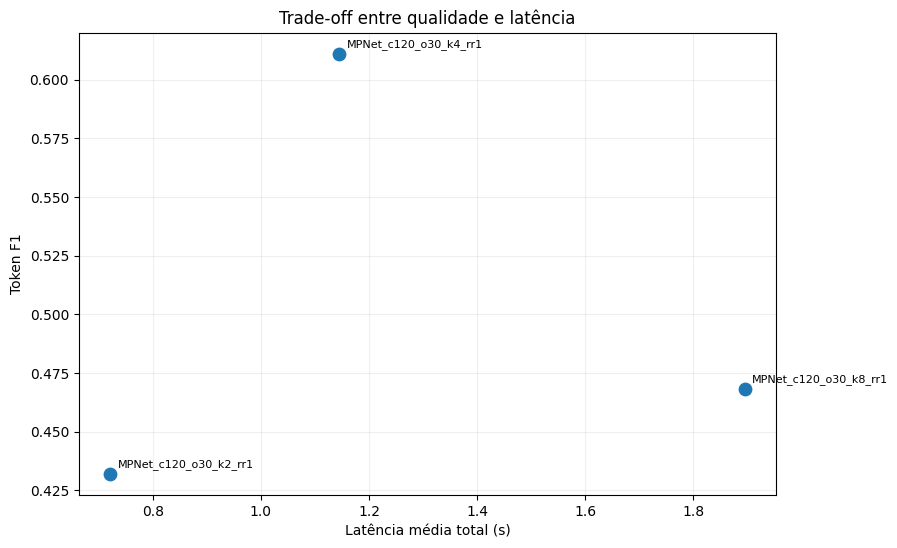

In [29]:
plt.figure(figsize=(9, 6))

plt.scatter(
    generation_summary["Total Latency s"],
    generation_summary["Token F1"],
    s=80,
)

for config_id, row in generation_summary.iterrows():
    plt.annotate(
        config_id,
        (
            row["Total Latency s"],
            row["Token F1"],
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Latência média total (s)")
plt.ylabel("Token F1")
plt.title("Trade-off entre qualidade e latência")
plt.grid(alpha=0.2)
plt.show()


## 27. Análise de casos problemáticos

As piores respostas da melhor configuração de geração são exibidas para inspeção manual.


In [30]:
best_generation_config = (
    generation_summary.index[0]
)

best_config_results = (
    generation_results[
        generation_results["Config"]
        == best_generation_config
    ]
    .sort_values(
        by=[
            "Token F1",
            "Groundedness",
        ],
        ascending=True,
    )
)

print(
    "Configuração analisada:",
    best_generation_config,
)

display(
    best_config_results[
        [
            "question",
            "reference_answer",
            "answer",
            "Token F1",
            "Groundedness",
            "Answer Relevance",
            "Context Tokens",
        ]
    ]
    .head(8)
)


Configuração analisada: MPNet_c120_o30_k4_rr1


,question,reference_answer,answer,Token F1,Groundedness,Answer Relevance,Context Tokens
0,What did the Edict do for Huguenots in France?,granted the Protestants equality with Catholics,abolished,0.000000,0,0,668
10,What modern city is located on the original Hu...,Cape Town,Brooklyn,0.000000,0,0,617
11,Who did BSkyB team up with because it was not ...,Freeview,National Grid Wireless,0.000000,0,0,566
9,What events are often associated with volcanis...,Deformational events,Volcanism and igneous activity,0.000000,1,1,553
3,What does the ctenophora use to swim?,‘combs’ – groups of cilia,The ctenophora uses cilia to swim.,0.333333,1,1,710
1,"What theatre was the best example of ""Polish m...",Wojciech Bogusławski Theatre,Wojciech Bogusławski Theatre,1.000000,0,0,631
4,Where do thrust faults form?,In the shallow crust,Shallow crust,1.000000,0,0,599
5,Full size working engines on what vehicles som...,ships,ships,1.000000,0,0,468


## 28. Comparação retrieval → generation

Uma questão importante em RAG é verificar se a configuração que vence no retrieval também vence na resposta final.

O melhor MRR pode não produzir o melhor Token F1.


In [31]:
retrieval_for_selected = (
    selected_configs
    .set_index("Config")[
        [
            "MRR",
            "Answer Support",
            "Source Precision@K",
            "Retrieval Latency ms/query",
        ]
    ]
)

end_to_end_comparison = (
    retrieval_for_selected
    .join(
        generation_summary[
            [
                "Token F1",
                "Groundedness",
                "Answer Relevance",
                "Context Tokens",
                "Total Latency s",
            ]
        ],
        how="inner",
    )
)

display(
    end_to_end_comparison.round(4)
)


,MRR,Answer Support,Source Precision@K,Retrieval Latency ms/query,Token F1,Groundedness,Answer Relevance,Context Tokens,Total Latency s
Config,,,,,,,,,
MPNet_c120_o30_k4_rr1,0.9917,1.0000,0.3219,41.0391,0.6111,0.2500,0.2500,615.3333,1.1455
MPNet_c120_o30_k8_rr1,0.9917,1.0000,0.1641,41.2822,0.4683,0.1667,0.1667,1198.1667,1.8951
MPNet_c120_o30_k2_rr1,0.9875,0.9875,0.6062,46.0259,0.4321,0.3333,0.3333,300.1667,0.7217


## 29. Conclusão

A conclusão é gerada com os resultados reais desta execução.


In [32]:
from IPython.display import Markdown, display

best_retrieval_row = (
    ranked_retrieval.iloc[0]
)

best_generation_config = (
    generation_summary.index[0]
)

best_generation_row = (
    generation_summary.loc[
        best_generation_config
    ]
)

rerank_mrr_without = (
    reranker_summary
    .loc[
        "Sem reranker",
        "MRR",
    ]
)

rerank_mrr_with = (
    reranker_summary
    .loc[
        "Com reranker",
        "MRR",
    ]
)

rerank_latency_without = (
    reranker_summary
    .loc[
        "Sem reranker",
        "Retrieval Latency ms/query",
    ]
)

rerank_latency_with = (
    reranker_summary
    .loc[
        "Com reranker",
        "Retrieval Latency ms/query",
    ]
)

conclusion = f'''
### Síntese dos resultados

#### Melhor configuração de retrieval

**{best_retrieval_row["Config"]}**

- Embedding: **{best_retrieval_row["Embedding"]}**
- Chunk size: **{int(best_retrieval_row["Chunk Size"])}**
- Overlap: **{int(best_retrieval_row["Overlap"])}**
- Top-K: **{int(best_retrieval_row["Top-K"])}**
- Reranker: **{bool(best_retrieval_row["Reranker"])}**
- MRR: **{best_retrieval_row["MRR"]:.3f}**
- Answer Support: **{best_retrieval_row["Answer Support"]:.3f}**
- Source Precision@K: **{best_retrieval_row["Source Precision@K"]:.3f}**

#### Efeito médio do reranking

- MRR sem reranker: **{rerank_mrr_without:.3f}**
- MRR com reranker: **{rerank_mrr_with:.3f}**

- Latência sem reranker: **{rerank_latency_without:.1f} ms/query**
- Latência com reranker: **{rerank_latency_with:.1f} ms/query**

#### Melhor configuração end-to-end

**{best_generation_config}**

- Token F1: **{best_generation_row["Token F1"]:.3f}**
- Groundedness: **{best_generation_row["Groundedness"]:.3f}**
- Answer Relevance: **{best_generation_row["Answer Relevance"]:.3f}**
- Context Tokens: **{best_generation_row["Context Tokens"]:.1f}**
- Latência total: **{best_generation_row["Total Latency s"]:.2f} s**

### Principal aprendizado

O melhor RAG não é necessariamente o pipeline que recupera a maior quantidade de contexto.

Há um equilíbrio entre:

**recall → precisão → contexto → grounding → qualidade → latência**

Aumentar Top-K pode elevar a chance de encontrar evidência, mas também pode reduzir a precisão do contexto.

Reranking pode melhorar a ordenação dos candidatos, porém adiciona custo computacional.

Chunks maiores podem aumentar a chance de preservar evidência, mas também enviam mais tokens irrelevantes ao LLM.

### Retrieval não é igual a generation

Este experimento também permite verificar se a configuração líder em MRR é a mesma que lidera Token F1.

Essa distinção é fundamental em sistemas RAG:

> otimizar apenas retrieval não garante otimização da resposta final.

### Sobre LLM-as-a-Judge

Groundedness e Answer Relevance foram avaliados por um LLM local.

Esses scores devem ser interpretados como **sinais auxiliares**, pois o avaliador também pode cometer erros e introduzir vieses.

### Limitações

- corpus relativamente pequeno;
- poucas perguntas na etapa de geração;
- apenas dois modelos de embeddings;
- apenas um reranker;
- apenas um LLM gerador;
- chunking baseado em palavras;
- ausência de busca lexical/híbrida;
- Answer Support utiliza correspondência textual;
- LLM-as-a-Judge não substitui avaliação humana;
- não foi calculado custo monetário porque o LLM é local;
- não há análise estatística de significância entre configurações.

### Próximos experimentos

1. BM25 + dense retrieval;
2. hybrid search;
3. semantic chunking;
4. mais embedding models;
5. diferentes rerankers;
6. nDCG e Recall@K;
7. bootstrap para intervalos de confiança;
8. avaliação humana;
9. APIs comerciais com custo real por token;
10. tracing e observabilidade por requisição.

### Próximo passo do repositório

O **Study 011 — Agent** muda o foco.

Até aqui, o sistema:

> recebe uma pergunta e recupera conhecimento.

No próximo estudo, o modelo deverá:

> **decidir quando e como utilizar ferramentas para executar uma tarefa.**

Isso introduz os conceitos de:

- tool calling;
- planejamento;
- estado;
- execução;
- recuperação de erros;
- avaliação de trajetórias.
'''

display(
    Markdown(conclusion)
)



### Síntese dos resultados

#### Melhor configuração de retrieval

**MPNet_c120_o30_k4_rr1**

- Embedding: **MPNet**
- Chunk size: **120**
- Overlap: **30**
- Top-K: **4**
- Reranker: **True**
- MRR: **0.992**
- Answer Support: **1.000**
- Source Precision@K: **0.322**

#### Efeito médio do reranking

- MRR sem reranker: **0.904**
- MRR com reranker: **0.978**

- Latência sem reranker: **0.0 ms/query**
- Latência com reranker: **42.0 ms/query**

#### Melhor configuração end-to-end

**MPNet_c120_o30_k4_rr1**

- Token F1: **0.611**
- Groundedness: **0.250**
- Answer Relevance: **0.250**
- Context Tokens: **615.3**
- Latência total: **1.15 s**

### Principal aprendizado

O melhor RAG não é necessariamente o pipeline que recupera a maior quantidade de contexto.

Há um equilíbrio entre:

**recall → precisão → contexto → grounding → qualidade → latência**

Aumentar Top-K pode elevar a chance de encontrar evidência, mas também pode reduzir a precisão do contexto.

Reranking pode melhorar a ordenação dos candidatos, porém adiciona custo computacional.

Chunks maiores podem aumentar a chance de preservar evidência, mas também enviam mais tokens irrelevantes ao LLM.

### Retrieval não é igual a generation

Este experimento também permite verificar se a configuração líder em MRR é a mesma que lidera Token F1.

Essa distinção é fundamental em sistemas RAG:

> otimizar apenas retrieval não garante otimização da resposta final.

### Sobre LLM-as-a-Judge

Groundedness e Answer Relevance foram avaliados por um LLM local.

Esses scores devem ser interpretados como **sinais auxiliares**, pois o avaliador também pode cometer erros e introduzir vieses.

### Limitações

- corpus relativamente pequeno;
- poucas perguntas na etapa de geração;
- apenas dois modelos de embeddings;
- apenas um reranker;
- apenas um LLM gerador;
- chunking baseado em palavras;
- ausência de busca lexical/híbrida;
- Answer Support utiliza correspondência textual;
- LLM-as-a-Judge não substitui avaliação humana;
- não foi calculado custo monetário porque o LLM é local;
- não há análise estatística de significância entre configurações.

### Próximos experimentos

1. BM25 + dense retrieval;
2. hybrid search;
3. semantic chunking;
4. mais embedding models;
5. diferentes rerankers;
6. nDCG e Recall@K;
7. bootstrap para intervalos de confiança;
8. avaliação humana;
9. APIs comerciais com custo real por token;
10. tracing e observabilidade por requisição.

### Próximo passo do repositório

O **Study 011 — Agent** muda o foco.

Até aqui, o sistema:

> recebe uma pergunta e recupera conhecimento.

No próximo estudo, o modelo deverá:

> **decidir quando e como utilizar ferramentas para executar uma tarefa.**

Isso introduz os conceitos de:

- tool calling;
- planejamento;
- estado;
- execução;
- recuperação de erros;
- avaliação de trajetórias.


## 30. Principais aprendizados

Ao concluir este estudo, devem ficar claros seis princípios de LLMOps:

### 1. RAG precisa de evals

Sem métricas, alterações de chunking, embeddings ou prompts são apenas tentativas.

### 2. Retrieval e generation devem ser avaliados separadamente

Um pipeline pode falhar antes mesmo de o LLM receber contexto.

### 3. Mais contexto não é automaticamente melhor

Contexto irrelevante consome tokens e pode prejudicar a resposta.

### 4. Reranking tem custo

CrossEncoders podem melhorar a ordenação, mas adicionam inferência adicional.

### 5. Métricas automáticas têm limitações

Exact Match, Token F1 e LLM-as-a-Judge medem aspectos diferentes.

### 6. O objetivo é otimizar o sistema

Em produção, a melhor configuração precisa equilibrar:

**qualidade + grounding + latência + custo + confiabilidade**


## Referências

- SQuAD 1.1 — Stanford Question Answering Dataset;
- Sentence Transformers — `encode_query()` e `encode_document()`;
- Sentence Transformers — CrossEncoder e retrieve-and-rerank;
- FAISS — busca vetorial exata;
- Qwen2.5-1.5B-Instruct;
- Hugging Face Transformers.

### Reprodutibilidade

Para a publicação definitiva:

1. execute todas as células no mesmo runtime;
2. preserve os outputs;
3. registre versões das bibliotecas;
4. informe hardware utilizado;
5. mantenha as sementes registradas;
6. não altere o conjunto de avaliação após observar os resultados.
